In [1]:
"""
# 13. Evaluación de modelos y análisis de confusión

## Objetivos
- Ir más allá del accuracy global y analizar errores por clase
- Comparar los tres modelos entrenados (MobileNetV2, EfficientNetB0, ResNet50)
- Identificar patrones de confusión sistemáticos
- Visualizar ejemplos mal clasificados para entender las limitaciones

## ¿Por qué el accuracy global no es suficiente?
Un modelo con 93% de accuracy global puede estar fallando sistemáticamente en clases específicas. El análisis de confusión
nos permite identificar exactamente dónde y por qué falla el modelo.

## Métricas clave

### Precision, Recall y F1-score
- "Precision": de todo lo que el modelo predijo como clase X, ¿cuánto era realmente X? → evita falsos positivos
- "Recall": de todo lo que era realmente clase X, ¿cuánto detectó el modelo? → evita falsos negativos
- "F1-score": media armónica de precision y recall →  balance entre ambas métricas

### Matriz de confusión
Muestra exactamente qué clases se confunden entre sí.
La diagonal principal son los aciertos — todo lo demás son errores.

### ¿Cuándo priorizar cada métrica?
| Métrica   | Priorizar cuando...                              |
|-----------|--------------------------------------------------|
| Precision | Los falsos positivos son costosos                |
| Recall    | Los falsos negativos son costosos                |
| F1        | Se busca balance general                         |
| Accuracy  | Las clases están balanceadas (como CIFAR-10)     |
"""

'\n# 13. Evaluación de modelos y análisis de confusión\n\n## Objetivos\n- Ir más allá del accuracy global y analizar errores por clase\n- Comparar los tres modelos entrenados (MobileNetV2, EfficientNetB0, ResNet50)\n- Identificar patrones de confusión sistemáticos\n- Visualizar ejemplos mal clasificados para entender las limitaciones\n\n## ¿Por qué el accuracy global no es suficiente?\nUn modelo con 93% de accuracy global puede estar fallando sistemáticamente en clases específicas. El análisis de confusión\nnos permite identificar exactamente dónde y por qué falla el modelo.\n\n## Métricas clave\n\n### Precision, Recall y F1-score\n- "Precision": de todo lo que el modelo predijo como clase X, ¿cuánto era realmente X? → evita falsos positivos\n- "Recall": de todo lo que era realmente clase X, ¿cuánto detectó el modelo? → evita falsos negativos\n- "F1-score": media armónica de precision y recall →  balance entre ambas métricas\n\n### Matriz de confusión\nMuestra exactamente qué clases se

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
import pandas as pd

tf.random.set_seed(42)
np.random.seed(42)

CLASS_NAMES = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print(f"TensorFlow version: {tf.__version__}")
print(f"Keras version:      {keras.__version__}")

TensorFlow version: 2.21.0
Keras version:      3.14.0


In [3]:
# Cargar los tres modelos
model_mv = keras.models.load_model("../models/11_mobilenetv2_finetuned.keras")
model_en = keras.models.load_model("../models/12_efficientnetb0_finetuned.keras")
model_rn = keras.models.load_model("../models/12_resnet50_finetuned.keras")

print("Modelos cargados ✓")

# Cargar CIFAR-10
(_, _), (x_test, y_test) = keras.datasets.cifar10.load_data()
x_test  = x_test.astype("float32") / 255.0
y_test  = y_test.flatten()

print(f"Test set: {x_test.shape}")

Modelos cargados ✓


C:\Users\Peter\ml_env\Lib\site-packages\keras\src\datasets\cifar.py:18: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  d = cPickle.load(f, encoding="bytes")


Test set: (10000, 32, 32, 3)


In [4]:
BATCH_SIZE = 64
IMG_SIZE   = 96

def make_test_ds(preprocess_fn):
    def preprocess(image, label):
        image = tf.cast(image * 255.0, tf.float32)
        image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))
        image = preprocess_fn(image)
        return image, label

    return (
        tf.data.Dataset.from_tensor_slices((x_test, y_test))
        .map(preprocess, num_parallel_calls=tf.data.AUTOTUNE)
        .batch(BATCH_SIZE)
        .prefetch(tf.data.AUTOTUNE)
    )

test_ds_mv = make_test_ds(keras.applications.mobilenet_v2.preprocess_input)
test_ds_en = make_test_ds(keras.applications.efficientnet.preprocess_input)
test_ds_rn = make_test_ds(keras.applications.resnet.preprocess_input)

print("Datasets listos ✓")

Datasets listos ✓


In [5]:
def get_predictions(model, test_ds):
    y_probs = model.predict(test_ds, verbose=0)
    y_pred  = np.argmax(y_probs, axis=1)
    return y_pred, y_probs

print("Generando predicciones...")
y_pred_mv, y_probs_mv = get_predictions(model_mv, test_ds_mv)
y_pred_en, y_probs_en = get_predictions(model_en, test_ds_en)
y_pred_rn, y_probs_rn = get_predictions(model_rn, test_ds_rn)

print("Predicciones generadas ✓")

Generando predicciones...
Predicciones generadas ✓


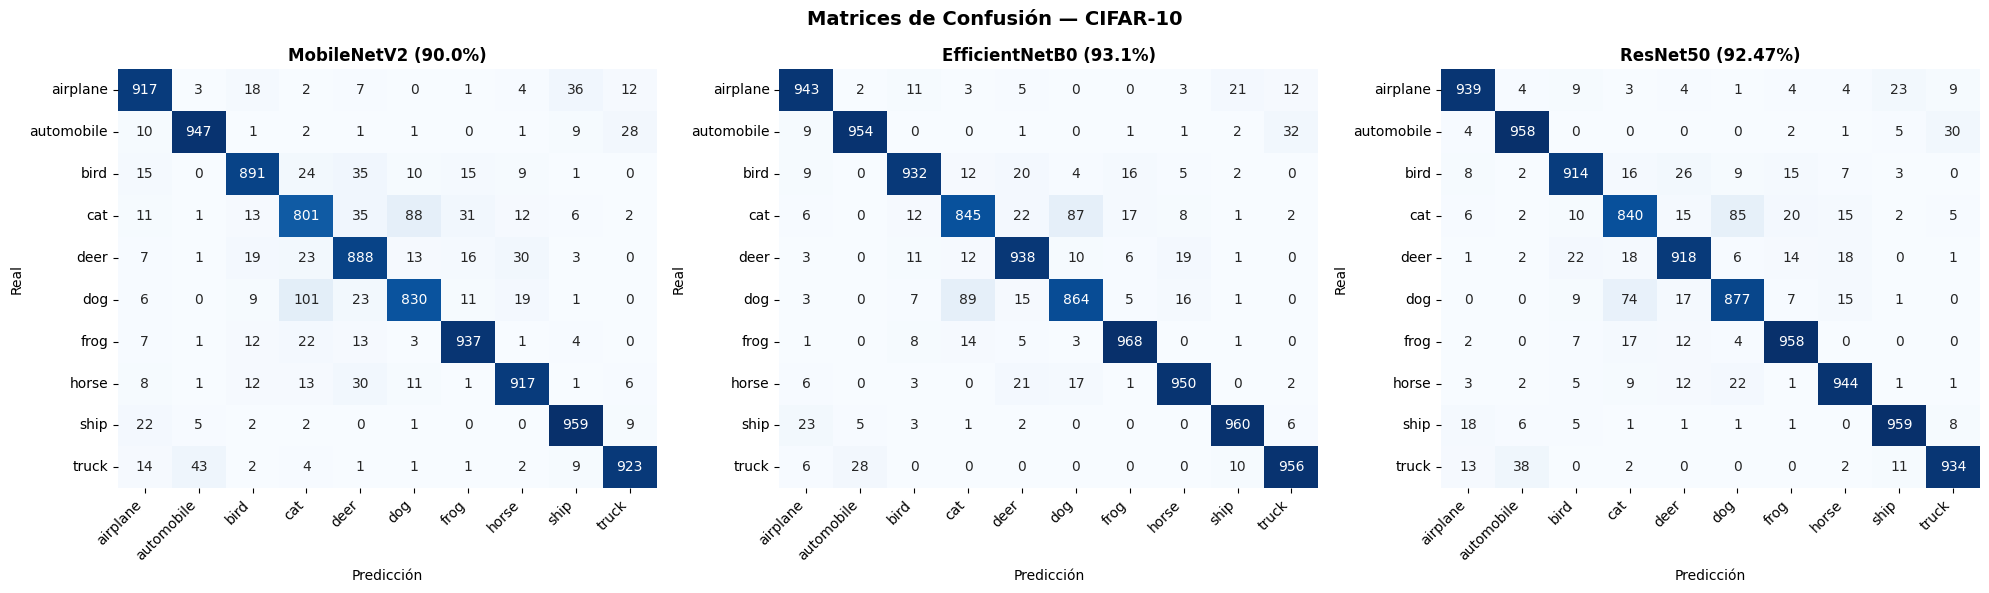

Figura guardada ✓


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

models_preds = {
    "MobileNetV2 (90.0%)":    y_pred_mv,
    "EfficientNetB0 (93.1%)": y_pred_en,
    "ResNet50 (92.47%)":      y_pred_rn,
}

for ax, (name, y_pred) in zip(axes, models_preds.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax, cbar=False
    )
    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Predicción")
    ax.set_ylabel("Real")
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right")

plt.suptitle("Matrices de Confusión — CIFAR-10", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../figures/13_confusion_matrices_comparison.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada ✓")

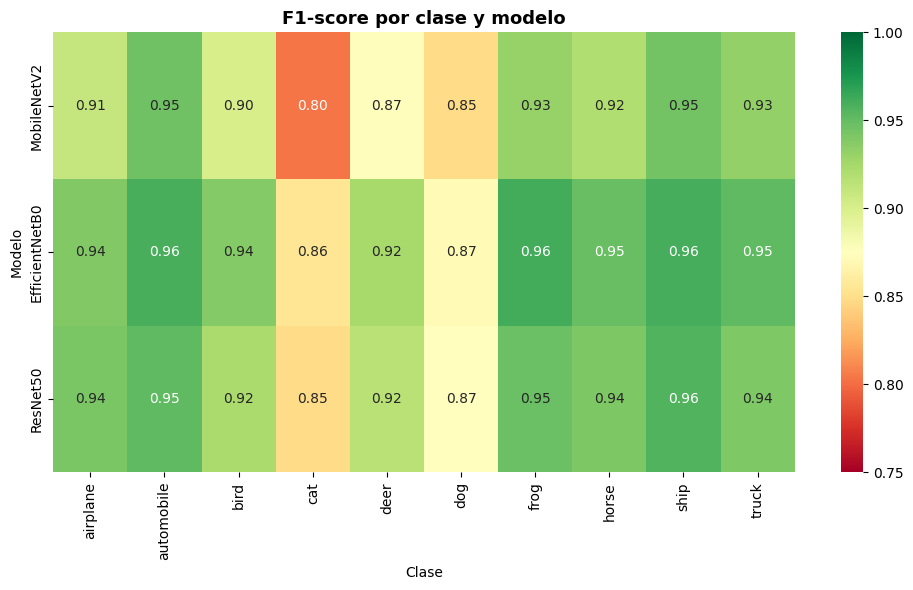


F1-score por clase:
            MobileNetV2  EfficientNetB0  ResNet50
airplane          0.909           0.939     0.942
automobile        0.946           0.959     0.951
bird              0.900           0.938     0.923
cat               0.803           0.855     0.848
deer              0.874           0.925     0.916
dog               0.848           0.871     0.875
frog              0.931           0.961     0.948
horse             0.919           0.949     0.941
ship              0.945           0.960     0.957
truck             0.932           0.951     0.940


In [12]:
from sklearn.metrics import f1_score

f1_mv = f1_score(y_test, y_pred_mv, average=None)
f1_en = f1_score(y_test, y_pred_en, average=None)
f1_rn = f1_score(y_test, y_pred_rn, average=None)

df_f1 = pd.DataFrame({
    "MobileNetV2":    f1_mv,
    "EfficientNetB0": f1_en,
    "ResNet50":       f1_rn,
}, index=CLASS_NAMES)

# Heatmap de F1 por clase
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    df_f1.T, annot=True, fmt=".2f", cmap="RdYlGn",
    vmin=0.75, vmax=1.0, ax=ax
)
ax.set_title("F1-score por clase y modelo", fontsize=13, fontweight="bold")
ax.set_xlabel("Clase")
ax.set_ylabel("Modelo")
plt.tight_layout()
plt.savefig("../figures/13_f1_per_class_heatmap.png",
            dpi=150, bbox_inches="tight")
plt.show()

print("\nF1-score por clase:")
print(df_f1.to_string(float_format="{:.3f}".format))

In [13]:
"""
## Ejemplos mal clasificados

Vamos a visualizar imágenes donde el modelo falla para entender
si los errores son "razonables" (imágenes ambiguas) o sistemáticos.

Nos enfocamos en "EfficientNetB0" por ser el mejor modelo,
y en las clases más difíciles: "cat" y "dog".
"""
def plot_misclassified(y_true, y_pred, y_probs, class_names,
                       target_class, n=10, title=""):
    """
    Muestra imágenes mal clasificadas para una clase específica.
    """
    # Índices donde la clase real es target_class y el modelo falló
    mask = (y_true == target_class) & (y_pred != target_class)
    indices = np.where(mask)[0]

    if len(indices) == 0:
        print(f"No hay errores para clase '{class_names[target_class]}'")
        return

    # Tomar los n con mayor confianza errónea (los errores más "seguros")
    confidences = y_probs[indices, y_pred[indices]]
    top_n = np.argsort(confidences)[::-1][:n]
    indices = indices[top_n]

    fig, axes = plt.subplots(2, 5, figsize=(15, 6))
    axes = axes.flatten()

    for i, idx in enumerate(indices):
        img = x_test[idx]
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        conf       = y_probs[idx, y_pred[idx]]

        axes[i].imshow(img)
        axes[i].set_title(
            f"Real: {true_label}\nPred: {pred_label} ({conf:.0%})",
            fontsize=9, color="red"
        )
        axes[i].axis("off")

    plt.suptitle(title, fontsize=13, fontweight="bold")
    plt.tight_layout()
    return fig

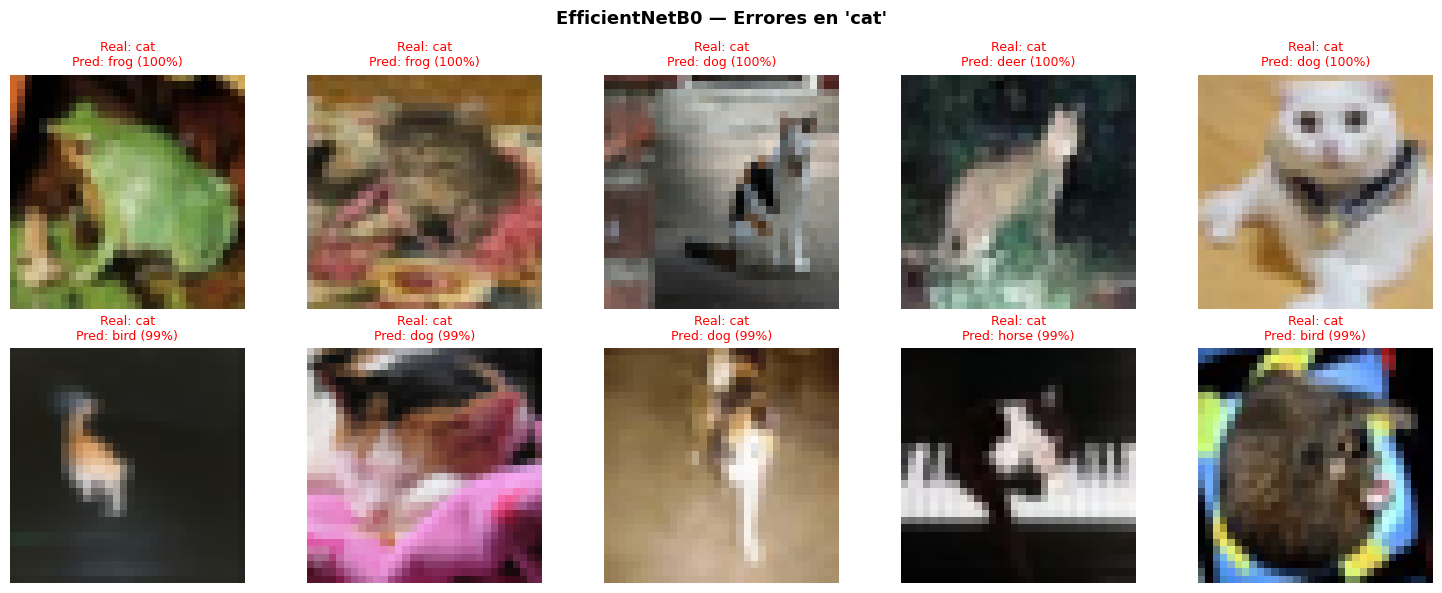

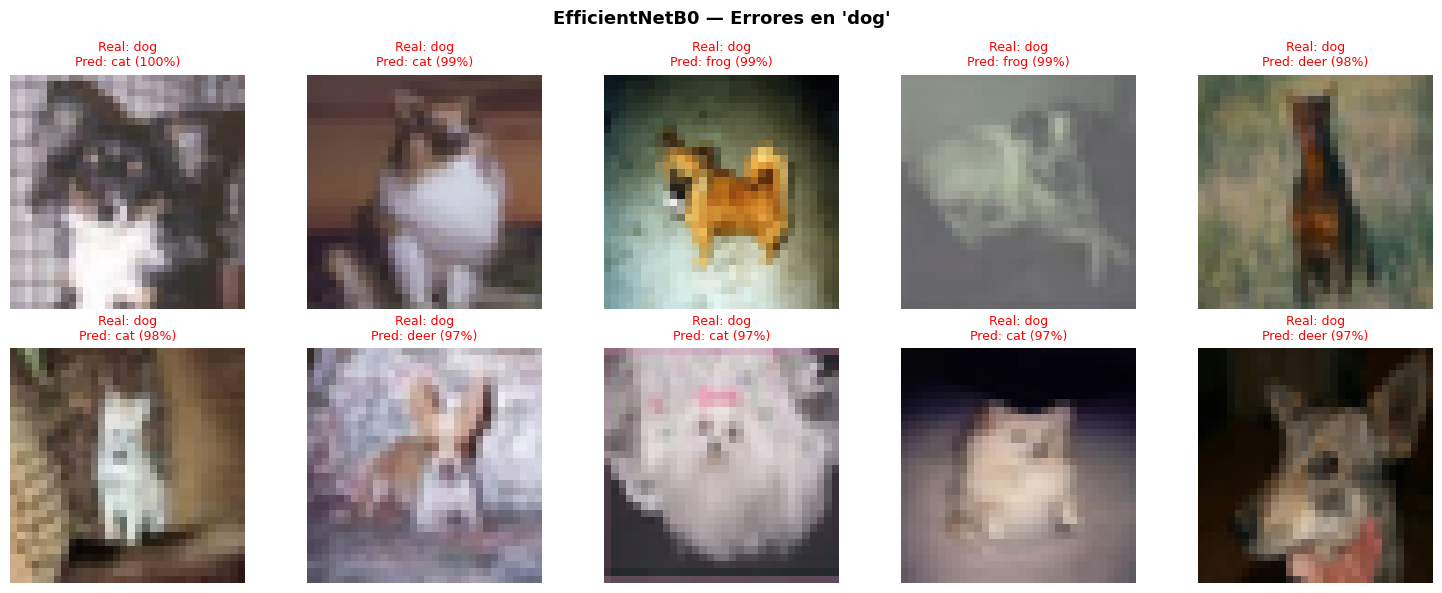

Figuras guardadas ✓


In [14]:
# Errores en CAT — EfficientNetB0
fig = plot_misclassified(
    y_test, y_pred_en, y_probs_en, CLASS_NAMES,
    target_class=3,  # cat
    n=10,
    title="EfficientNetB0 — Errores en 'cat'"
)
plt.savefig("../figures/13_misclassified_cat.png", dpi=150, bbox_inches="tight")
plt.show()

# Errores en DOG — EfficientNetB0
fig = plot_misclassified(
    y_test, y_pred_en, y_probs_en, CLASS_NAMES,
    target_class=5,  # dog
    n=10,
    title="EfficientNetB0 — Errores en 'dog'"
)
plt.savefig("../figures/13_misclassified_dog.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figuras guardadas ✓")

Top 10 confusiones — EfficientNetB0:
      Real   Predicho  Errores
       dog        cat       89
       cat        dog       87
automobile      truck       32
     truck automobile       28
      ship   airplane       23
       cat       deer       22
  airplane       ship       21
     horse       deer       21
      bird       deer       20
      deer      horse       19


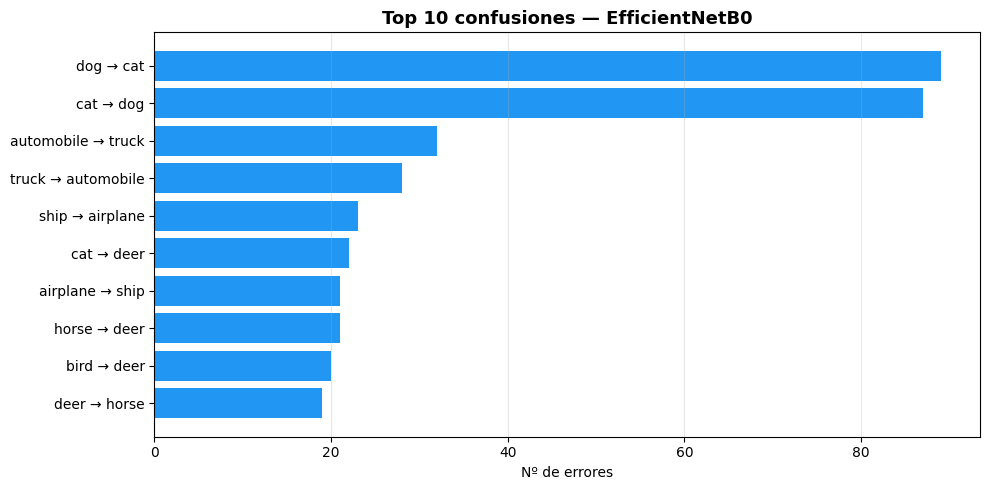

Figura guardada ✓


In [15]:
# Top confusiones por par de clases en EfficientNetB0
cm_en = confusion_matrix(y_test, y_pred_en)

# Extraer pares fuera de la diagonal
confusions = []
for i in range(len(CLASS_NAMES)):
    for j in range(len(CLASS_NAMES)):
        if i != j and cm_en[i, j] > 0:
            confusions.append({
                "Real":      CLASS_NAMES[i],
                "Predicho":  CLASS_NAMES[j],
                "Errores":   cm_en[i, j]
            })

df_conf = pd.DataFrame(confusions).sort_values("Errores", ascending=False)

print("Top 10 confusiones — EfficientNetB0:")
print(df_conf.head(10).to_string(index=False))

# Barplot
fig, ax = plt.subplots(figsize=(10, 5))
top10 = df_conf.head(10)
labels = [f"{r['Real']} → {r['Predicho']}" for _, r in top10.iterrows()]
ax.barh(labels[::-1], top10["Errores"].values[::-1], color="#2196F3")
ax.set_title("Top 10 confusiones — EfficientNetB0", fontsize=13, fontweight="bold")
ax.set_xlabel("Nº de errores")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("../figures/13_top_confusions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada ✓")

In [16]:
print("=" * 55)
print("   RESUMEN FINAL — Notebook 13")
print("=" * 55)
print(f"\n  {'Clase':<12} {'MobileNetV2':>12} {'EfficientNetB0':>15} {'ResNet50':>10}")
print("  " + "-" * 51)
for cls in CLASS_NAMES:
    f1_mv_ = df_f1.loc[cls, "MobileNetV2"]
    f1_en_ = df_f1.loc[cls, "EfficientNetB0"]
    f1_rn_ = df_f1.loc[cls, "ResNet50"]
    print(f"  {cls:<12} {f1_mv_:>12.3f} {f1_en_:>15.3f} {f1_rn_:>10.3f}")
print("=" * 55)

   RESUMEN FINAL — Notebook 13

  Clase         MobileNetV2  EfficientNetB0   ResNet50
  ---------------------------------------------------
  airplane            0.909           0.939      0.942
  automobile          0.946           0.959      0.951
  bird                0.900           0.938      0.923
  cat                 0.803           0.855      0.848
  deer                0.874           0.925      0.916
  dog                 0.848           0.871      0.875
  frog                0.931           0.961      0.948
  horse               0.919           0.949      0.941
  ship                0.945           0.960      0.957
  truck               0.932           0.951      0.940


In [ ]:
"""
## Conclusiones

### Patrones de confusión sistemáticos
- "cat" es la clase más difícil en los tres modelos (F1: 0.80–0.86).
  Se confunde principalmente con "dog" y "deer" — comparten texturas de pelaje similares y poses parecidas en imágenes 32×32.
- "dog" es la segunda clase más difícil (F1: 0.85–0.88), confundida frecuentemente con "cat".
- Estas confusiones son "razonables": incluso para humanos, distinguir perros y gatos en imágenes de baja resolución es difícil.

### Comparación entre modelos
- "EfficientNetB0" domina en todas las clases sin excepción.
- "ResNet50" es competitivo con EfficientNetB0 en dog y bird, pero pierde en el resto — a un costo computacional mucho mayor.
- "MobileNetV2" es sorprendentemente fuerte dado su tamaño:
  solo 3–5 puntos de F1 por debajo de EfficientNetB0 en la mayoría de clases, con 7x menos parámetros.

### ¿Qué nos dice el análisis de errores?
Los errores de alta confianza (modelo equivocado pero seguro) aparecen principalmente en imágenes ambiguas o de mala calidad.
Esto sugiere que el modelo aprendió features relevantes pero la resolución de CIFAR-10 (32×32) impone un techo natural.

### Próximo notebook
"14_gradcam_and_interpretability.ipynb" — Grad-CAM para visualizar qué regiones de la imagen activan las predicciones del modelo
y entender si aprende features semánticamente relevantes.